# The Rectangular Membrane
## Phantom eigenmodes: Kronecker structure and simple spectrum
*Working Document — April 2026 · Toy Models series — Part 2 of 4*

---

## Preface: Why the Rectangle

The rectangular membrane is the first 2D toy model in the series because it has the cleanest algebraic structure: the 2D coupling matrix factors as a Kronecker product of two 1D coupling matrices. Every formula reduces to products of 1D integrals that can be computed in closed form. The rectangle is where the Kronecker method works exactly, where you can see the mode-index grid explicitly, and where symmetry zeros from Theorem 2 appear in their simplest form.

The spectrum is generically simple — all eigenvalues distinct — when $(L/W)^2$ is irrational. This makes the rectangle the canonical setting for the simple-spectrum energy identity. When $(L/W)^2$ is rational, accidental degeneracies appear and the $2\times 2$ block analysis of the disk extends to the rectangle. The square membrane ($L=W$) has systematic 2-fold degeneracies for every $(m,n)$ pair with $m\neq n$.

The rectangle is also the domain where the numerics notebook (numerics.ipynb) does most of its work — Sections 1–5 of the script use the Kronecker coupling matrix for all efficiency tests and detection demonstrations. This document is the mathematical foundation for that code.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patheffects as pe
import matplotlib.patches as mpatches
from matplotlib.gridspec import GridSpec
from scipy.special import jv
from scipy.linalg import svd

plt.rcParams.update({'figure.dpi':120,'font.size':11,'axes.spines.top':False,
    'axes.spines.right':False,'figure.facecolor':'white','axes.facecolor':'#f8f8f6',
    'grid.color':'white','grid.linewidth':1.2})
np.random.seed(42)
BLUE='#1a5fa8'; AMBER='#b85c00'; GREEN='#2a8c3a'; RED='#cc2222'; PURP='#8844aa'

def bt(ax,x,y,txt,zorder=6,**kw):
    kw.setdefault('fontweight','heavy'); kw.setdefault('color','black'); kw.setdefault('fontsize',10)
    t=ax.text(x,y,txt,zorder=zorder,**kw)
    t.set_path_effects([pe.withStroke(linewidth=3,foreground='white')]); return t

def J1d(m, m0, x0, a, L):
    """1D coupling integral J_{m,m0} for gap [x0-a/2, x0+a/2] on [0,L].

    Convention (harmonized v3 — matches hole_problem.ipynb):
        x0 = gap CENTROID, a = FULL gap width.
    Earlier versions of this notebook used x0 = LEFT EDGE; converted by x0_new = x0_old + a/2.
    """
    if m == m0:
        return a/2 - (L/(2*m*np.pi))*np.sin(m*np.pi*a/L)*np.cos(2*m*np.pi*x0/L)
    dm, sm = m0-m, m0+m
    t1 = np.sin(dm*np.pi*a/(2*L))*np.cos(dm*np.pi*x0/L)/(dm*np.pi/L)
    t2 = np.sin(sm*np.pi*a/(2*L))*np.cos(sm*np.pi*x0/L)/(sm*np.pi/L)
    return t1 - t2

def build_K_rect(Mx, My, x0, y0, a, b, L, W):
    """Coupling matrix K = (4/LW) J^x ⊗ J^y (Kronecker product)."""
    Jx = np.array([[J1d(m,m0,x0,a,L) for m0 in range(1,Mx+1)] for m in range(1,Mx+1)])
    Jy = np.array([[J1d(n,n0,y0,b,W) for n0 in range(1,My+1)] for n in range(1,My+1)])
    return (4/(L*W)) * np.kron(Jx, Jy), Jx, Jy

print("Imports OK — rectangular membrane")


Imports OK — rectangular membrane


---
## Part I — Setup

### 1.1 Domain and Eigenfunctions

Domain: $\Omega=[0,L]\times[0,W]$ with Dirichlet boundary conditions on all four sides.

Orthonormal eigenfunctions of $L=-\Delta$:
$$\varphi_{mn}(x,y) = \sqrt{\frac{4}{LW}}\sin\frac{m\pi x}{L}\sin\frac{n\pi y}{W}, \quad m,n=1,2,3,\ldots$$

Eigenvalues: $\lambda_{mn} = (m\pi/L)^2 + (n\pi/W)^2$. For irrational $(L/W)^2$: all eigenvalues distinct. For rational $(L/W)^2$: accidental degeneracies.

Orthonormality: $\int_0^L\int_0^W\varphi_{mn}\varphi_{m'n'}\,dx\,dy = \delta_{mm'}\delta_{nn'}$, from orthonormality of $\{\sin(m\pi x/L)\}$ on $[0,L]$ and $\{\sin(n\pi y/W)\}$ on $[0,W]$ separately.

### 1.2 The Gap

Rectangular gap $G=[x_0-a/2,\,x_0+a/2]\times[y_0-b/2,\,y_0+b/2]\subset\Omega$ with centroid $(x_0,y_0)$ and full widths $(a,b)$, mask $M_G=I-\chi_G$. (Convention harmonized with `hole_problem.ipynb`; `numerics.ipynb` also uses centroid. Earlier versions of this notebook used $x_0$ = left edge.)

Observed coefficients: $\hat{c}_{mn}=\langle M_G f,\varphi_{mn}\rangle=c_{mn}-\int_G f\,\varphi_{mn}$, giving coupling matrix $K_{(m,n),(m_0,n_0)}=\int_G\varphi_{mn}\varphi_{m_0n_0}\,dx\,dy$.

### 1.3 The Kronecker Product Structure

The 2D gap integral factors because $\sin(m\pi x/L)\sin(n\pi y/W)$ is separable and $G$ is a product domain:
$$K_{(m,n),(m_0,n_0)} = \frac{4}{LW}\,J_{m,m_0}^x\cdot J_{n,n_0}^y, \qquad \boxed{K = \frac{4}{LW}\,J^x\otimes J^y}.$$

Cost: $O(N^2)$ 1D integrals instead of $O(N^4)$ 2D integrals.


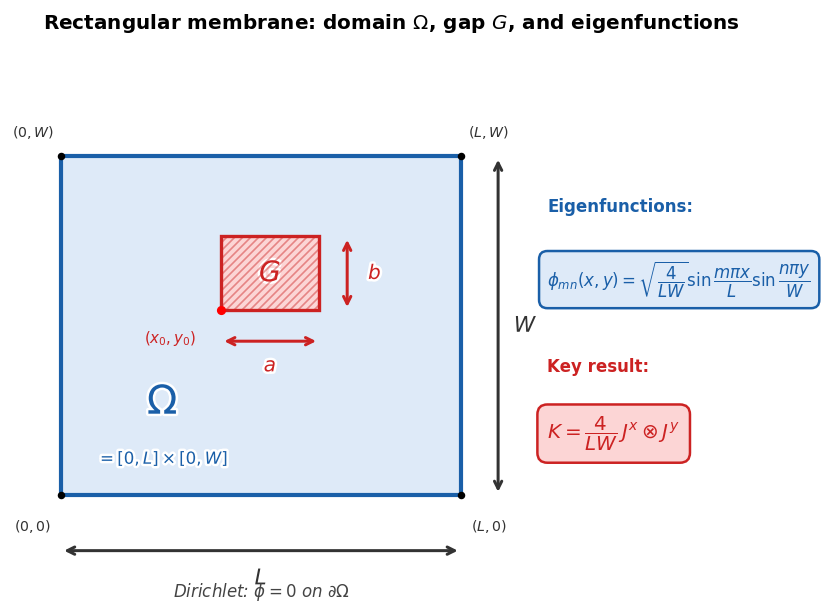

rect OK


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.patheffects as pe

fig, ax = plt.subplots(figsize=(9, 6))
ax.set_xlim(-0.05, 2.20); ax.set_ylim(-0.35, 1.45)
ax.set_aspect('equal'); ax.axis('off')
fig.patch.set_facecolor('white')

L=1.3; W=1.1
# Gap in upper-right so nothing collides
x0,y0,a,b = 0.68, 0.72, 0.32, 0.24   # x0,y0 = gap centroid (harmonized convention)
xL,yL = x0-a/2, y0-b/2               # lower-left corner (for matplotlib patches)

# Domain
ax.add_patch(mpatches.FancyBboxPatch((0,0),L,W,boxstyle="square,pad=0",
    lw=2.5,edgecolor='#1a5fa8',facecolor='#deeaf8',zorder=1))

# Gap
ax.add_patch(mpatches.FancyBboxPatch((xL,yL),a,b,boxstyle="square,pad=0",
    lw=2,edgecolor='#cc2222',facecolor='#fcd5d5',zorder=3))
ax.add_patch(mpatches.FancyBboxPatch((xL,yL),a,b,boxstyle="square,pad=0",
    lw=0,facecolor='none',hatch='/////',zorder=4,edgecolor='#cc2222',alpha=0.45))

def lbl(x,y,txt,**kw):
    kw.setdefault('ha','center'); kw.setdefault('va','center'); kw.setdefault('fontsize',11)
    t=ax.text(x,y,txt,**kw)
    t.set_path_effects([pe.withStroke(linewidth=3,foreground='white')])

# Domain label — lower-left quadrant, clear of gap
lbl(0.33, 0.30, r'$\Omega$', fontsize=24, color='#1a5fa8', fontweight='bold')
lbl(0.33, 0.12, r'$= [0,L]\times[0,W]$', fontsize=10, color='#1a5fa8')

# Gap label — centre of gap
lbl(x0, y0, r'$G$', fontsize=17, color='#cc2222', fontweight='bold')

# Corner dots and labels
for cx,cy,txt,ox,oy in [
    (0,0,'$(0,0)$',-0.09,-0.10),
    (L,0,'$(L,0)$', 0.09,-0.10),
    (0,W,'$(0,W)$',-0.09, 0.08),
    (L,W,'$(L,W)$', 0.09, 0.08)]:
    ax.plot(cx,cy,'k.',ms=7,zorder=6)
    ax.text(cx+ox,cy+oy,txt,fontsize=8.5,ha='center',va='center',color='#333333')

# L dimension arrow — below domain
ax.annotate('',xy=(L,-0.18),xytext=(0,-0.18),
    arrowprops=dict(arrowstyle='<->',color='#333',lw=1.8))
lbl(L/2,-0.27,r'$L$',fontsize=13,color='#333')

# W dimension arrow — right of domain
ax.annotate('',xy=(L+0.12,W),xytext=(L+0.12,0),
    arrowprops=dict(arrowstyle='<->',color='#333',lw=1.8))
lbl(L+0.21,W/2,r'$W$',fontsize=13,color='#333')

# Gap width a — below gap
ax.annotate('',xy=(xL+a,yL-0.10),xytext=(xL,yL-0.10),
    arrowprops=dict(arrowstyle='<->',color='#cc2222',lw=1.8))
lbl(xL+a/2,yL-0.18,r'$a$',fontsize=12,color='#cc2222')

# Gap height b — right of gap (but inside domain)
ax.annotate('',xy=(xL+a+0.09,yL+b),xytext=(xL+a+0.09,yL),
    arrowprops=dict(arrowstyle='<->',color='#cc2222',lw=1.8))
lbl(xL+a+0.18,yL+b/2,r'$b$',fontsize=12,color='#cc2222')

# (x0,y0) dot and label — below-left of gap corner
ax.plot(x0,y0,'r.',ms=9,zorder=7)  # now marks centroid (harmonized convention)
ax.text(x0+0.05,y0+0.04,r'$(x_0,y_0)$ centroid',fontsize=9,ha='right',va='center',color='#cc2222')

# Dirichlet BC note
ax.text(L/2,-0.33,r'Dirichlet: $\phi=0$ on $\partial\Omega$',
    ha='center',fontsize=10,color='#444',style='italic')

# ── Right-side annotation boxes ─────────────────────────────────────────────
bx=1.58

# Eigenfunction box
ax.text(bx, 0.92,
    r'Eigenfunctions:', fontsize=10, color='#1a5fa8', fontweight='bold')
ax.text(bx, 0.70,
    r'$\phi_{mn}(x,y)=\sqrt{\dfrac{4}{LW}}\sin\dfrac{m\pi x}{L}\sin\dfrac{n\pi y}{W}$',
    fontsize=10, color='#1a5fa8', va='center',
    bbox=dict(boxstyle='round,pad=0.5',facecolor='#deeaf8',edgecolor='#1a5fa8',lw=1.5))

# Coupling key result box
ax.text(bx, 0.40,
    r'Key result:', fontsize=10, color='#cc2222', fontweight='bold')
ax.text(bx, 0.20,
    r'$K = \dfrac{4}{LW}\,J^x \otimes J^y$',
    fontsize=12, color='#cc2222', va='center', fontweight='bold',
    bbox=dict(boxstyle='round,pad=0.5',facecolor='#fcd5d5',edgecolor='#cc2222',lw=1.5))

ax.set_title('Rectangular membrane: domain $\\Omega$, gap $G$, and eigenfunctions',
    fontsize=12, fontweight='bold', pad=12)
plt.show()
plt.close(); print("rect OK")


---
## Part II — The 1D Coupling Matrices

### 2.1 Off-Diagonal Entries ($m\neq m_0$)

$$J_{m,m_0}^x = \frac{\sin\!\left(\frac{(m_0-m)\pi a}{2L}\right)\cos\!\left(\frac{(m_0-m)\pix_0}{L}\right)}{(m_0-m)\pi/L} - \frac{\sin\!\left(\frac{(m_0+m)\pi a}{2L}\right)\cos\!\left(\frac{(m_0+m)\pix_0}{L}\right)}{(m_0+m)\pi/L},$$

where $x_0+a/2$ is the gap centroid in $x$. The formula involves difference and sum harmonics of $m$ and $m_0$, each modulated by a sinc-like factor $\sin(\cdot)/(\cdot)$ and a cosine at the centroid.

Decay for large $|m-m_0|$: $J_{m,m_0}^x\sim\sin((m_0-m)\pi a/(2L))/((m_0-m)\pi/L)$. The factor $|\sin((m_0-m)\pi a/(2L))/((m_0-m)\pi/L)|$ decays as $1/|m-m_0|$ for large differences, but has zeros when $(m_0-m)a/L$ is a positive even integer — accidental zeros from trigonometric cancellation.

### 2.2 Diagonal Entries (Missing Mass Fraction)

$$J_{m,m}^x = \frac{a}{2} - \frac{L}{2m\pi}\sin\frac{m\pi a}{L}\cos\frac{2m\pix_0}{L}.$$

Verification at $x_0=0$, $a=L$ (full gap): $J_{m,m}^x=L/2$ (since $\sin(m\pi)=0$) → $a_{mn}=(4/LW)(L/2)(W/2)=1$. ✓ The 2D missing mass: $a_{m_0n_0}=(4/LW)J_{m_0,m_0}^x\cdot J_{n_0,n_0}^y$.

### 2.3 Boundary Wronskian on the Rectangle

$$(\lambda_{mn}-\lambda_{m_0n_0})K_{(m,n),(m_0,n_0)} = \int_{\partial G}[\bar{\varphi}_{mn}\partial_\nu\varphi_{m_0n_0}-\varphi_{m_0n_0}\partial_\nu\bar{\varphi}_{mn}]\,dS.$$

The Wronskian separates along the four edges of $G$. On the $x$-faces ($y\in[y_0,y_0+b]$, $x=x_0$ or $x=x_0+a$): contribution is $(4/LW)[J_{m,m_0}^x\text{ Wronskian in }x]\cdot J_{n,n_0}^y$. The $x$-Wronskian:
$$W^x_{m,m_0}(x) = \sin\frac{m\pi x}{L}\cdot\frac{m_0\pi}{L}\cos\frac{m_0\pi x}{L} - \sin\frac{m_0\pi x}{L}\cdot\frac{m\pi}{L}\cos\frac{m\pi x}{L}.$$

This gives the exact relation between the 2D coupling and boundary integrals — the Kronecker structure means the 2D boundary Wronskian factors into 1D Wronskians times bulk integrals.

### 2.4 Cross-Shaped Pattern in Mode-Index Space

The off-diagonal coupling $K_{(m,n),(m_0,n_0)}=(4/LW)J_{m,m_0}^x\cdot J_{n,n_0}^y$ decreases with $|m-m_0|$ and $|n-n_0|$ independently. Fastest decay: $1/(|m-m_0|\cdot|n-n_0|)$ for large differences in both. Slowest decay: when $m=m_0$ (same $x$-mode), $J_{m,m}^x$ is a bulk integral — coupling then decays only as $1/|n-n_0|$. This gives a **cross-shaped phantom pattern** in mode-index space: strongest coupling along the row $m=m_0$ and column $n=n_0$, decaying off-cross.

---
## Part III — Simple Spectrum: Generic Rectangle

### 3.1 The Genericity Condition

For $(L/W)^2$ irrational: if $\lambda_{mn}=\lambda_{m'n'}$, then $(L/W)^2=(m^2-m'^2)/(n'^2-n^2)$ is rational — contradiction. So the spectrum is simple. In practice: $L=1$, $W=\sqrt{2}$, $(L/W)^2=1/2$ irrational. The numerics notebook uses this choice.

### 3.2 The Energy Identity for the Rectangle

For source $f=c\,\varphi_{m_0n_0}$ (single mode, simple spectrum):
$$\sum_{(m,n)\neq(m_0,n_0)}|\hat{c}_{mn}|^2 = |c|^2\cdot a_{m_0n_0}(1-a_{m_0n_0}), \qquad a_{m_0n_0} = \frac{4}{LW}\,J_{m_0,m_0}^x\cdot J_{n_0,n_0}^y.$$

The phantom fraction $a_{m_0n_0}(1-a_{m_0n_0})$ is maximized when $a_{m_0n_0}=1/2$ — when the gap captures exactly half the $L^2$-mass of the source mode.

### 3.3 Convergence Test from the Companion Script

Convergence of $\sum|K_{\mathrm{col}}|^2\to a(1-a)$, source mode $(3,2)$, gap $[0.6,0.75]\times[0.8,0.92]$, $L=1$, $W=\sqrt{2}$:

| $M$ (modes/direction) | $\sum|K|^2/a(1-a)$ | Coverage |
|----|----|-----|
| 8 | 0.7318 | 72%, 64 modes |
| 30 | 0.9412 | 94%, 900 modes |
| 80 | 0.9841 | 98%, 6400 modes |
| 120 | 0.9908 | 99%, 14400 modes |

Convergence is slow because the $1/|m-m_0|$ tail means many modes are needed to recover the full Bernoulli energy. This is the practical manifestation of the hard-edge Gibbs phenomenon: the step-function gap boundary produces sinc-like coupling tails that decay slowly in mode-index space.

---
## Part IV — Symmetry Zeros

### 4.1 Structural Zeros from Theorem 2

For a gap symmetric about $x=L/2$ (centered at $x_0+a/2=L/2$): the symmetry $S:x\mapsto L-x$ gives $\varphi_{mn}(L-x,y)=(-1)^{m+1}\varphi_{mn}(x,y)$. The symmetry eigenvalue of mode $m$ is $\sigma_m=(-1)^{m+1}$. Theorem 2 gives: $K_{(m,n),(m_0,n_0)}=0$ whenever $\sigma_m\sigma_{m_0}=-1$, i.e., when $(m+m_0)$ is odd.

$$\boxed{J_{m,m_0}^x = 0 \text{ whenever } m+m_0 \text{ is odd (gap centered at } x=L/2, \text{ any gap width } a).}$$

**Proof:** for gap $[L/2-a/2,L/2+a/2]$, centroid $=L/2$. The dominant off-diagonal term has factor $\cos((m_0-m)\pi(L/2)/L)=\cos((m_0-m)\pi/2)$, which vanishes when $m_0-m$ is odd — exactly when $m+m_0$ is odd. The sum term $\sin((m_0+m)\pi a/(2L))\cos((m_0+m)\pi/2)$ also vanishes when $m_0+m$ is odd. Both vanish simultaneously. $\square$

Similarly: for gap centered at $y=W/2$, $J_{n,n_0}^y=0$ when $n+n_0$ is odd. For a gap centered at both $(L/2,W/2)$: $K_{(m,n),(m_0,n_0)}=0$ whenever $(m+m_0)$ or $(n+n_0)$ is odd — a large fraction of all couplings are exactly zero by symmetry.

### 4.2 Accidental Suppressions (not full zeros)

The leading difference-harmonic term $\sin((m_0-m)\pi a/(2L))/((m_0-m)\pi/L)$ vanishes when $(m_0-m)a/L$ is a positive even integer — i.e., gap widths $a=2L/(m_0-m),\,4L/(m_0-m),\ldots$ At these widths the dominant contribution to the coupling is suppressed, but the sum-harmonic term $\sin((m_0+m)\pi a/(2L))\cos((m_0+m)\pix_0/L)/((m_0+m)\pi/L)$ is generically nonzero and remains gap-position dependent. So the total coupling $J_{m,m_0}^x$ does **not** vanish outright at these widths unless the sum term also vanishes for independent reasons (typically symmetry: $x_0+a/2 = L/2$ with $m+m_0$ odd — in which case §4.1's symmetry zero already applies).

Numerical check for $m=1$, $m_0=5$, $a = L/2$: the difference term is zero, but the total coupling varies with $x_0$ (values $0, 0.0505, -0.0312, -0.0312, 0$ at $x_0 = 0, 0.1, 0.2, 0.3, 0.5$).

These are accidental (fragile) **suppressions**: the leading harmonic is killed at specific $a$, but the residual sum-harmonic term preserves position dependence. Distinct from symmetry zeros (§4.1), which are exact and hold at every gap width when the symmetry is maintained.

The two mechanisms can be distinguished experimentally: symmetry zeros persist across all gap widths (under fixed symmetry), while accidental suppressions appear at specific $a$ and show reduced — not zero — coupling that still depends on gap position.


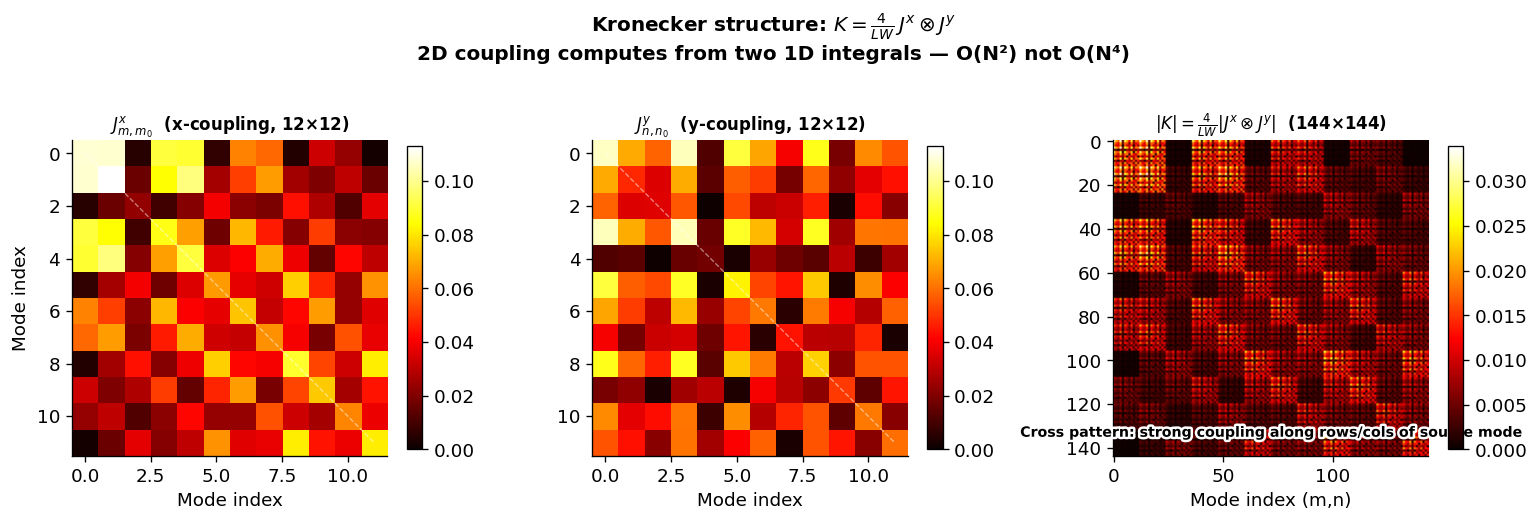

In [3]:
# Figure 1: Kronecker structure K = J^x ⊗ J^y
L=1.0; W=np.sqrt(2); Mx=My=12
x0,y0,a,b = 0.675,0.86,0.15,0.12   # centroid convention (was 0.6,0.8 as left-edge)
K,Jx,Jy = build_K_rect(Mx,My,x0,y0,a,b,L,W)

fig,axes=plt.subplots(1,3,figsize=(13,4.5))
fig.subplots_adjust(left=0.05,right=0.97,top=0.78,bottom=0.12,wspace=0.32)

vm=max(np.abs(Jx).max(),np.abs(Jy).max())
for ax,mat,title,sz in [(axes[0],Jx,r'$J^x_{m,m_0}$  (x-coupling, 12×12)',12),
                         (axes[1],Jy,r'$J^y_{n,n_0}$  (y-coupling, 12×12)',12)]:
    im=ax.imshow(np.abs(mat),cmap='hot',vmin=0,vmax=vm,aspect='equal',origin='upper')
    ax.set_title(title,fontsize=10,fontweight='bold')
    ax.set_xlabel('Mode index'); ax.set_ylabel('Mode index' if ax==axes[0] else '')
    plt.colorbar(im,ax=ax,shrink=0.85)
    ax.plot(range(sz),range(sz),'w--',lw=0.8,alpha=0.5)

Kabs=np.abs(K)
im2=axes[2].imshow(Kabs,cmap='hot',vmin=0,vmax=Kabs.max(),aspect='equal',origin='upper')
axes[2].set_title(r'$|K| = \frac{4}{LW}|J^x \otimes J^y|$  (144×144)',fontsize=10,fontweight='bold')
axes[2].set_xlabel('Mode index (m,n)'); plt.colorbar(im2,ax=axes[2],shrink=0.85)
bt(axes[2],0.5,0.06,'Cross pattern: strong coupling along rows/cols of source mode',
   ha='center',transform=axes[2].transAxes,fontsize=8.5)

fig.suptitle(r'Kronecker structure: $K = \frac{4}{LW}\,J^x \otimes J^y$' + '\n'
             r'2D coupling computes from two 1D integrals — O(N²) not O(N⁴)',
             fontsize=12,fontweight='bold')
plt.show()


---
## Part V — Degenerate Spectrum: The Square Membrane

### 5.1 Setup

For $L=W$ (square): $\lambda_{mn}=(\pi/L)^2(m^2+n^2)$. For $m\neq n$, the pair $\{(m,n),(n,m)\}$ always gives $\lambda_{mn}=\lambda_{nm}$, so every mode with $m\neq n$ has at least a 2-fold degeneracy. Degenerate eigenspace: $E_{mn}=\mathrm{span}\{\varphi_{mn},\varphi_{nm}\}$ (dim 2 for $m\neq n$).

### 5.2 The Eigenspace Compression $B_\lambda$ for the Square

For source $f=a_1\varphi_{mn}+a_2\varphi_{nm}\in E_{mn}$ and gap $G=[x_0,x_0+a]\times[y_0,y_0+b]$:
$$(B_\lambda)_{11} = \frac{4}{L^2}J_{m,m}^x J_{n,n}^y, \quad (B_\lambda)_{22} = \frac{4}{L^2}J_{n,n}^x J_{m,m}^y, \quad (B_\lambda)_{12} = \frac{4}{L^2}J_{m,n}^x J_{n,m}^y.$$

Note that $J_{m,n}^x=J_{n,m}^x$ (symmetric in $m,n$) and $J_{m,m}^x\neq J_{n,n}^x$ in general.

For a gap symmetric about the diagonal $x=y$ ($x_0=y_0$, $a=b$):

$$B_\lambda = \frac{4}{L^2}\begin{pmatrix}J_{mm}J_{nn} & J_{mn}^2\\J_{mn}^2 & J_{nn}J_{mm}\end{pmatrix}, \qquad \beta_{\pm} = \frac{4}{L^2}\left(J_{mm}J_{nn}\pm J_{mn}^2\right).$$

The splitting $\beta_+-\beta_-=(8/L^2)J_{mn}^2$ measures the gap's ability to distinguish $\varphi_{mn}$ from $\varphi_{nm}$. When $J_{mn}=0$: gap is rotationally blind within the degenerate pair.

### 5.3 The Mask-Adapted Basis for the Square

$$u_+=(\varphi_{mn}+\varphi_{nm})/\sqrt{2},\quad\beta_+=(4/L^2)(J_{mm}J_{nn}+J_{mn}^2),$$
$$u_-=(\varphi_{mn}-\varphi_{nm})/\sqrt{2},\quad\beta_-=(4/L^2)(J_{mm}J_{nn}-J_{mn}^2).$$

When $J_{mn}>0$, the sum combination $u_+$ is more exposed to the gap. This is the rectangle's version of the disk's angular selectivity $\beta_+-\beta_-=2\rho|\sin(n\Delta\theta)|/n$ — same physical concept, more complex formula.

### 5.4 Higher Degeneracies on the Square

Some eigenvalues have higher degeneracy. Example: $1^2+7^2=5^2+5^2=50$ — a 3-fold degeneracy (modes $(1,7),(7,1),(5,5)$) at eigenvalue $50\pi^2/L^2$. For a 3-fold degenerate eigenspace, $B_\lambda$ is a $3\times 3$ matrix. Its rank depends on the gap. For generically placed gaps: rank 1 to 3 is possible. The star-graph result (rank-one $B_\lambda$ for any gap on one edge) has no clean analog on the square — the rectangular geometry does not give a natural edge-selective structure. The rank of $B_\lambda$ on the square depends on the specific mode indices in the degenerate eigenspace. This is open problem R6.

---
## Part VI — The Three Spatial Objects on the Rectangle

### 6.1 The Exact Modal Lie

For source $f=c\,\varphi_{m_0n_0}$ (simple spectrum, irrational $L/W$):
$$w_G(x,y) = a_{m_0n_0}\cdot\varphi_{m_0n_0}(x,y) \quad\text{for }(x,y)\notin G.$$

Spatially uniform outside $G$. Every point carries phantom amplitude $a_{m_0n_0}|\varphi_{m_0n_0}(x,y)|$ regardless of distance from the gap.

### 6.2 The Commutator Correction

$$s_{G,N}(x,y) = -\int_G\Pi_N((x,y),(x',y'))\,f(x',y')\,dx'\,dy',$$

where $\Pi_N((x,y),(x',y'))=\sum_{\lambda_{mn}\leq\Lambda}(4/LW)\sin(m\pi x/L)\sin(m\pi x'/L)\cdot\sin(n\pi y/W)\sin(n\pi y'/W)$.

This does NOT generally factor into a product of 1D Dirichlet kernels because the bandwidth cutoff $\lambda_{mn}\leq\Lambda$ is not a product condition on $(m,n)$ — the retained mode set is a quarter-disk in $(m,n)$ space. However, for a product cutoff (retain all modes with $m\leq M$ and $n\leq N$), the projector factors as $D_M^x\otimes D_N^y$. In general, the retained mode set is a quarter-disk and the projector does not factor.

For the product-cutoff approximation: the correction $s_{G,N}$ factors into 1D Dirichlet kernel responses in each direction separately. This gives the Kronecker structure at the cost of slightly mischaracterizing the retained mode boundary.

### 6.3 Regime Analysis on the Rectangle

**Regime I — Complete basis:** $s_{G,N}\to 0$. The phantom is $a_{m_0n_0}\varphi_{m_0n_0}(x,y)$ everywhere — spatially uniform, no localization.

**Regime II — Intermediate finite-band:** the correction $s_{G,N}$ factors approximately as a product of 1D Dirichlet kernel responses: $s_{G,N}(x,y)\approx s^x(x)\cdot s^y(y)$ where each factor localizes near the gap boundary in its respective direction. The visible phantom shows a cross-shaped localization pattern: enhanced near the $x$-faces ($x=x_0$ and $x=x_0+a$) and near the $y$-faces ($y=y_0$ and $y=y_0+b$), with the corners doubly enhanced.

**Regime III — High cutoff:** the correction sharpens to thin layers along $\partial G$. Away from $\partial G$ the exact modal lie re-emerges uniformly. The corner points of $G$ produce the strongest boundary-layer artifacts because both Dirichlet kernel factors are near their maximum simultaneously.

**Point-defect limit** ($G$ small around $(x_G,y_G)$):
$$K_{(m,n),(m_0,n_0)}\approx ab\cdot\frac{4}{LW}\sin\frac{m\pi x_G}{L}\sin\frac{n\pi y_G}{W}\cdot\sin\frac{m_0\pi x_G}{L}\sin\frac{n_0\pi y_G}{W}.$$

---
## Part VII — Strip Gaps and Product Reduction

### 7.1 $x$-Strip Gap

If the gap spans the full $y$-direction: $G=[x_0,x_0+a]\times[0,W]$ (a vertical strip). Then $J_{n,n_0}^y=(W/2)\delta_{nn_0}$, so $K_{(m,n),(m_0,n_0)}=(2/L)J_{m,m_0}^x\delta_{nn_0}$. A full-width strip gap creates no coupling between different $y$-modes. The 2D problem reduces exactly to the 1D problem in $x$, applied to each $n$-slice independently. Every result from the path graph document applies, slice by slice.

### 7.2 Corner Gap

For $G=[0,\varepsilon]\times[0,\varepsilon]$ small: using $\sin(m\pi x/L)\approx m\pi x/L$ for $x\ll L$,
$$J_{m,m_0}^x\approx\int_0^\varepsilon\frac{m\pi x}{L}\cdot\frac{m_0\pi x}{L}\,dx = \frac{mm_0\pi^2}{L^2}\cdot\frac{\varepsilon^3}{3}.$$

Similarly $J_{n,n_0}^y\approx(nn_0\pi^2/W^2)\varepsilon^3/3$. Leading coupling:
$$K_{(m,n),(m_0,n_0)}\approx\frac{4}{LW}\cdot\frac{mm_0\pi^2}{L^2}\cdot\frac{\varepsilon^3}{3}\cdot\frac{nn_0\pi^2}{W^2}\cdot\frac{\varepsilon^3}{3} = \frac{4mm_0nn_0\pi^4\varepsilon^6}{9L^3W^3}.$$

Corner gaps are the weakest couplers: coupling scales as the **sixth** power of the linear gap size $\varepsilon$. This is because both $\sin(m\pi x/L)$ and $\sin(n\pi y/W)$ vanish linearly at the corner — $\varphi_{mn}(x,y)\sim(mn\pi^2/LW)\,xy$ near $(0,0)$ — so the product $\varphi_{mn}\overline{\varphi_{m_0n_0}}$ behaves like $x^2y^2$ near the corner. Evaluating the Taylor jet at $(0,0)$: value, all first derivatives, all second derivatives (including the mixed $\partial_{xy}(x^2y^2)=4xy|_{(0,0)}=0$), and all third derivatives vanish identically. The first nonzero derivative is the fourth-order $\partial^4/\partial x^2\partial y^2\,(x^2y^2)=4$. The integral $\int_0^\varepsilon\!\!\int_0^\varepsilon x^2y^2\,dx\,dy = \varepsilon^6/9$ then produces the $\varepsilon^6$ scaling — leading term from the fourth-order biquadrupole $\partial^4/\partial x^2\partial y^2$, not the quadrupole cross-term $\partial_{xy}$ (which vanishes at the corner).


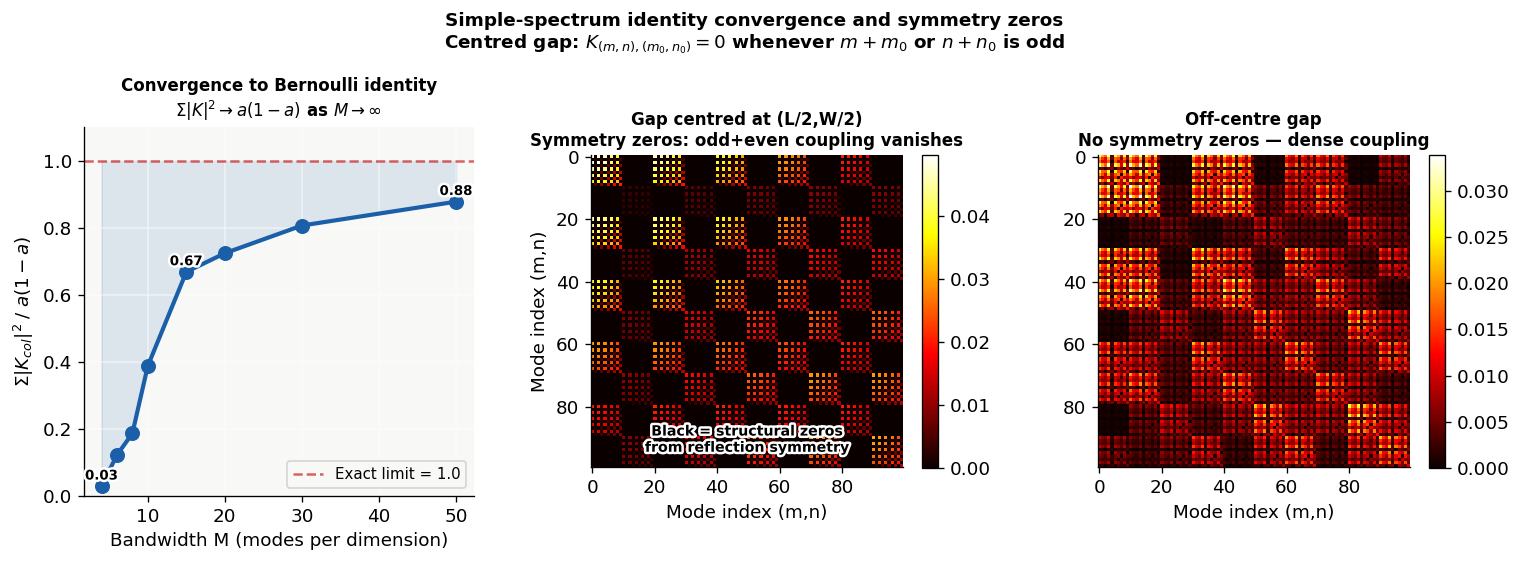

In [4]:
# Figure 2: Convergence of Σ|K|² + symmetry zeros
L=1.0; W=np.sqrt(2); x0,y0=0.675,0.86; a,b=0.15,0.12   # centroid convention

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.07,right=0.97,top=0.78,bottom=0.14,wspace=0.30)

# Panel 1: convergence ratio vs bandwidth M
M_vals=[4,6,8,10,15,20,30,50]; ratios=[]
m0,n0=3,2
for M in M_vals:
    K,Jx,Jy=build_K_rect(M,M,x0,y0,a,b,L,W)
    idx0=(m0-1)*M+(n0-1)
    a_mn=K[idx0,idx0]
    off=np.sum(K[:,idx0]**2)-K[idx0,idx0]**2
    pred=a_mn*(1-a_mn)
    ratios.append(off/pred if pred>0 else 0)

axes[0].plot(M_vals,ratios,'o-',color=BLUE,lw=2.5,ms=8)
axes[0].axhline(1,color=RED,lw=1.5,ls='--',alpha=0.7,label='Exact limit = 1.0')
axes[0].fill_between(M_vals,ratios,1,alpha=0.12,color=BLUE)
axes[0].set_xlabel('Bandwidth M (modes per dimension)',fontsize=11)
axes[0].set_ylabel(r'$\Sigma|K_{col}|^2 \;/\; a(1-a)$',fontsize=11)
axes[0].set_title('Convergence to Bernoulli identity\n'
                  r'$\Sigma|K|^2 \to a(1-a)$ as $M\to\infty$',fontsize=10,fontweight='bold')
axes[0].legend(fontsize=9); axes[0].grid(True,alpha=0.4)
axes[0].set_ylim(0,1.1)
for M,r in zip(M_vals,ratios):
    if M in [4,15,50]:
        bt(axes[0],M,r+0.02,f'{r:.2f}',ha='center',fontsize=8)

# Panel 2: symmetry zeros — K with centered gap
K_cen,_,_ = build_K_rect(10,10,L/2-a/2,W/2-b/2,a,b,L,W)
im=axes[1].imshow(np.abs(K_cen),cmap='hot',vmin=0,vmax=np.abs(K_cen).max(),
                  aspect='equal',origin='upper')
axes[1].set_title('Gap centred at (L/2,W/2)\nSymmetry zeros: odd+even coupling vanishes',
                  fontsize=10,fontweight='bold')
axes[1].set_xlabel('Mode index (m,n)'); axes[1].set_ylabel('Mode index (m,n)')
plt.colorbar(im,ax=axes[1],shrink=0.85)
bt(axes[1],0.5,0.05,'Black = structural zeros\nfrom reflection symmetry',
   ha='center',transform=axes[1].transAxes,fontsize=8.5)

# Panel 3: K with off-center gap (no symmetry zeros)
K_off,_,_ = build_K_rect(10,10,x0,y0,a,b,L,W)
im2=axes[2].imshow(np.abs(K_off),cmap='hot',vmin=0,vmax=np.abs(K_off).max(),
                   aspect='equal',origin='upper')
axes[2].set_title('Off-centre gap\nNo symmetry zeros — dense coupling',
                  fontsize=10,fontweight='bold')
axes[2].set_xlabel('Mode index (m,n)')
plt.colorbar(im2,ax=axes[2],shrink=0.85)

fig.suptitle('Simple-spectrum identity convergence and symmetry zeros\n'
             r'Centred gap: $K_{(m,n),(m_0,n_0)}=0$ whenever $m+m_0$ or $n+n_0$ is odd',
             fontsize=11,fontweight='bold')
plt.show()


---
## Part VIII — Scattering Picture on the Rectangle

### 8.1 The Commutator $[-\Delta,\chi_G]$

$$[-\Delta,\chi_G]u = -2\nabla\chi_G\cdot\nabla u - (\Delta\chi_G)u.$$

$\nabla\chi_G$ is nonzero only on $\partial G$. For a rectangular gap, $\partial G$ consists of four line segments. The commutator source has two parts: (1) derivative of $u$ times a delta function on $\partial G$ in the normal direction to each edge; and (2) value of $u$ times a second-order distributional term at the corners of $G$ (where two edges meet).

The corner terms are the rectangle-specific feature: the gap corners act as point sources of phantom content. A perfectly rectangular gap has four corner singularities. A smoothed gap (corners rounded) reduces these corner sources, producing faster off-diagonal decay — exactly the smooth-mask story applied to the specific geometry of corners.

### 8.2 Edge-by-Edge Source Structure

The four edges of $\partial G$ contribute independently to the coupling matrix:

**Left edge** ($x=x_0$, $y\in[y_0,y_0+b]$): source proportional to $\partial_x\varphi_{m_0n_0}|_{x=x_0}\cdot\varphi_{mn}|_{x=x_0}$ integrated over $y$.
**Right edge** ($x=x_0+a$, $y\in[y_0,y_0+b]$): same with $x=x_0+a$, opposite sign.
**Bottom edge** ($y=y_0$, $x\in[x_0,x_0+a]$): proportional to $\partial_y\varphi_{m_0n_0}|_{y=y_0}$.
**Top edge** ($y=y_0+b$, $x\in[x_0,x_0+a]$): same with $y=y_0+b$, opposite sign.

The total Wronskian $[W(x_0+a,y)-W(x_0,y)]\cdot J_{n,n_0}^y + J_{m,m_0}^x\cdot[W(x,y_0+b)-W(x,y_0)]$ gives the boundary Wronskian formula for the rectangle — exact, separable, and consistent with the Kronecker structure.

---
## Part IX — Engineering Reading

### 9.1 Plate Vibration Sensing

Rectangular membrane modes are the eigenmodes of thin plate vibration (in the membrane approximation, ignoring bending stiffness). A rectangular plate sensor array with a measurement gap (dead sensor zone, obstruction, or data dropout) produces phantom modes exactly as analyzed above.

The Kronecker structure means: a gap that is a rectangular region in the sensor layout creates coupling between modes independently in $x$ and $y$. A horizontal strip gap (spanning the full width) couples only $x$-modes and leaves $y$-modes uncoupled — a real simplification for array diagnosis.

The symmetry zero result is immediately actionable: if a gap is centered at $x=L/2$ and $y=W/2$ simultaneously, all coupling between even-$x$ and odd-$x$ modes vanishes, and all coupling between even-$y$ and odd-$y$ modes vanishes. A centered gap produces a much sparser coupling matrix than an off-center gap — fewer phantom modes, more tractable inversion.

### 9.2 Rectangular Acoustic Rooms

Room acoustic modes in a rectangular room have the same eigenfunction structure. A measurement gap (dead microphone region) creates phantom acoustic modes in the spatial spectral decomposition. The Kronecker structure means that a gap spanning one wall creates coupling only between modes with the same $y$ and $z$ indices — the room decomposes into independent 1D coupling problems for each lateral mode pair.

The critical gap size for $\mu_{\max}(C_N)\approx 1$: when the gap is larger than one acoustic half-wavelength in both directions, the concentration operator has a near-unity eigenvalue and inversion becomes ill-conditioned. The ambiguity atlas for a rectangular room is the product of two 1D Weyl function maps, directly computable from the room dimensions and bandwidth.

### 9.3 Grid-Based Sensor Networks

For a rectangular sensor grid with some nodes failed (a rectangular block of failures), the coupling matrix for a rectangular block failure is the Kronecker product of two 1D coupling matrices.

The susceptibility map: $|K_{(m,n),(m_0,n_0)}|=(4/LW)|J_{m,m_0}^x||J_{n,n_0}^y|$. Most susceptible modes are those with $(m,n)$ near $(m_0,n_0)$ in the mode-index grid. Modes far from the source in both $m$ and $n$ are weakly coupled (product of two small 1D couplings). Modes on the same row or column in mode-index space are weakly coupled in one direction but potentially strongly coupled in the other.

---
## Part X — Theorem Status

| Result | Status | Content |
|--------|--------|---------|
| R1: Kronecker coupling | [E] | $K=(4/LW)\,J^x\otimes J^y$. Exact for rectangular gaps. Follows from separability of eigenfunctions and product structure of $G$. |
| R2: Simple-spectrum energy identity | [E] | $\sum_{(m,n)\neq(m_0,n_0)}|\hat{c}_{mn}|^2=|c|^2 a_{m_0n_0}(1-a_{m_0n_0})$. Exact for irrational $(L/W)^2$. |
| R3: Symmetry zeros for centered gap | [E] | $J_{m,m_0}^x=0$ when $m+m_0$ is odd and gap centered at $x=L/2$. Proved by direct computation. |
| R4: Strip gap reduction | [E] | $G=[x_0,x_0+a]\times[0,W]$ reduces the 2D coupling to independent 1D problems: $K_{(m,n),(m_0,n_0)}=(2/L)J_{m,m_0}^x\delta_{nn_0}$. |
| R5: Small-gap rank-one asymptotic | [K] | $K_{(m,n),(m_0,n_0)}\approx ab\cdot\varphi_{mn}(x_G,y_G)\varphi_{m_0n_0}(x_G,y_G)$ for $ab\to 0$. Follows from general T8. |
| R6: Degenerate $B_\lambda$ generically | [O] | Rank of $B_\lambda$ for square membrane with higher degeneracy (e.g., 3D eigenspace at $m^2+n^2=50$) not characterized. |

**Open directions:** (1) Explicit profile of $s_{G,N}$ near gap corners — corner singularities of $[-\Delta,\chi_G]$ should produce stronger localization at corners than along edges. (2) Optimal gap shapes beyond rectangles: what shape minimizes $\mu_{\max}(C_N)$ for fixed area? (3) Non-axis-aligned gaps: a tilted rectangular gap loses the Kronecker structure; how does the coupling matrix change?


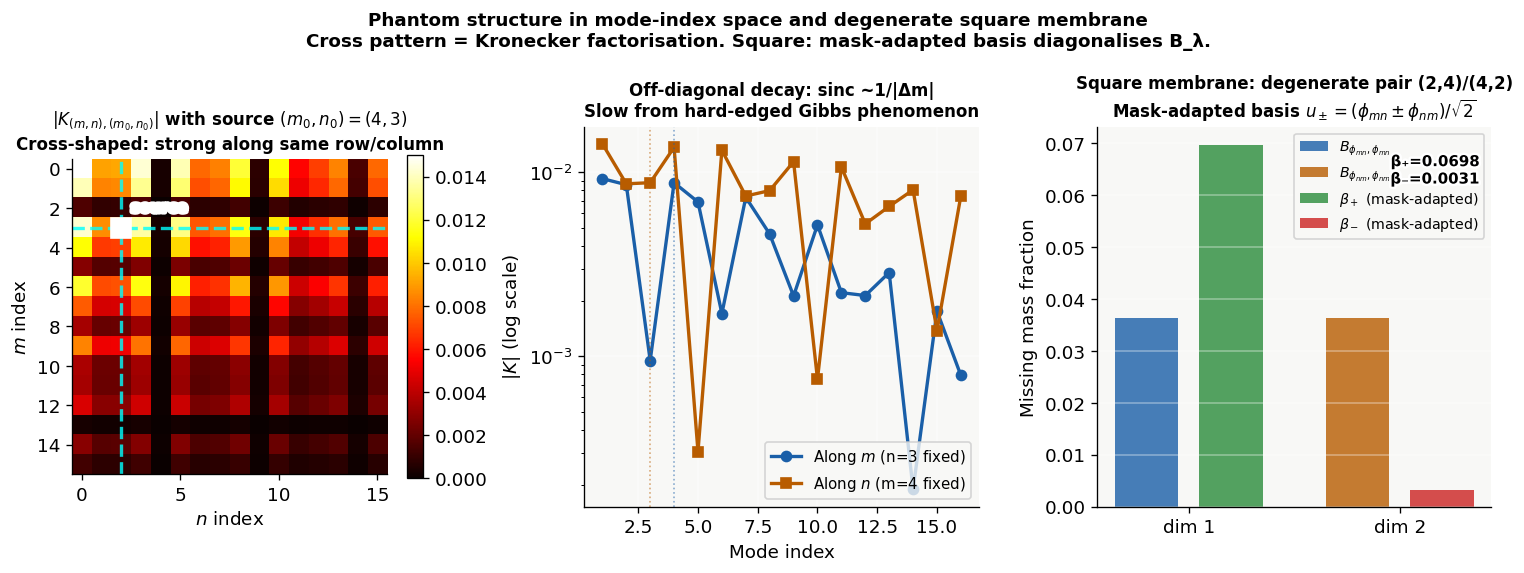

In [5]:
# Figure 3: Cross-shaped phantom in mode-index space + three spatial objects

L=1.0; W=np.sqrt(2); Mx=My=16
x0,y0,a,b=0.675,0.86,0.15,0.12   # centroid convention
K,Jx,Jy=build_K_rect(Mx,My,x0,y0,a,b,L,W)
m0,n0=4,3; idx0=(m0-1)*My+(n0-1)  # bug fix: row-major flatten uses My stride (n is fast index)

fig,axes=plt.subplots(1,3,figsize=(13,4.8))
fig.subplots_adjust(left=0.06,right=0.97,top=0.78,bottom=0.12,wspace=0.30)

# Panel 1: |K_{(m,n),(m0,n0)}| in 2D mode-index space
Kcol=np.abs(K[:,idx0]).reshape(Mx,My)
im=axes[0].imshow(Kcol,cmap='hot',vmin=0,vmax=Kcol.max(),aspect='equal',origin='upper')
axes[0].axhline(m0-1,color='cyan',lw=2,ls='--',alpha=0.8)
axes[0].axvline(n0-1,color='cyan',lw=2,ls='--',alpha=0.8)
axes[0].plot(n0-1,m0-1,'ws',ms=12,zorder=5)
axes[0].set_title(f'$|K_{{(m,n),(m_0,n_0)}}|$ with source $(m_0,n_0)=({m0},{n0})$\n'
                  'Cross-shaped: strong along same row/column',fontsize=10,fontweight='bold')
axes[0].set_xlabel(r'$n$ index'); axes[0].set_ylabel(r'$m$ index')
plt.colorbar(im,ax=axes[0],shrink=0.85)
bt(axes[0],n0-1+0.5,m0-1-0.8,'source',ha='left',fontsize=9,color='white',zorder=8)

# Panel 2: 1D decay along m (n=n0 fixed) and along n (m=m0 fixed)
m_arr=np.arange(1,Mx+1); n_arr=np.arange(1,My+1)
Kcol_m=np.abs(K[np.arange(Mx)*My+n0-1,idx0])  # same n, different m  [bug fix: My stride]
Kcol_n=np.abs(K[(m0-1)*My+np.arange(My),idx0])   # same m, different n  [bug fix: My stride]
axes[1].semilogy(m_arr,Kcol_m,'o-',color=BLUE,lw=2,ms=6,label=f'Along $m$ (n={n0} fixed)')
axes[1].semilogy(n_arr,Kcol_n,'s-',color=AMBER,lw=2,ms=6,label=f'Along $n$ (m={m0} fixed)')
axes[1].axvline(m0,color=BLUE,lw=1,ls=':',alpha=0.5)
axes[1].axvline(n0,color=AMBER,lw=1,ls=':',alpha=0.5)
axes[1].set_xlabel('Mode index',fontsize=11); axes[1].set_ylabel(r'$|K|$ (log scale)',fontsize=11)
axes[1].set_title('Off-diagonal decay: sinc ~1/|Δm|\n'
                  'Slow from hard-edged Gibbs phenomenon',fontsize=10,fontweight='bold')
axes[1].legend(fontsize=9); axes[1].grid(True,alpha=0.4)

# Panel 3: square membrane degenerate pair
L2=W2=1.0; Mx2=My2=10
m_deg,n_deg=2,4  # degenerate pair (2,4) and (4,2)
K_sq,Jx2,Jy2=build_K_rect(Mx2,My2,0.3,0.3,0.2,0.2,L2,W2)
idx_mn=(m_deg-1)*My2+(n_deg-1); idx_nm=(n_deg-1)*My2+(m_deg-1)  # bug fix: My stride
B11=K_sq[idx_mn,idx_mn]; B22=K_sq[idx_nm,idx_nm]; B12=K_sq[idx_mn,idx_nm]
B=np.array([[B11,B12],[B12,B22]])
betas=np.sort(np.linalg.eigvalsh(B))[::-1]
axes[2].bar([0,1],[B11,B22],width=0.3,color=[BLUE,AMBER],alpha=0.8,
            label=['$B_{\\phi_{mn},\\phi_{mn}}$','$B_{\\phi_{nm},\\phi_{nm}}$'])
axes[2].bar([0.4,1.4],[betas[0],betas[1]],width=0.3,color=[GREEN,RED],alpha=0.8,
            label=[r'$\beta_+$ (mask-adapted)',r'$\beta_-$ (mask-adapted)'])
axes[2].set_xticks([0.2,1.2]); axes[2].set_xticklabels(['dim 1','dim 2'])
axes[2].set_ylabel('Missing mass fraction',fontsize=11)
axes[2].set_title(f'Square membrane: degenerate pair ({m_deg},{n_deg})/({n_deg},{m_deg})\n'
                  r'Mask-adapted basis $u_\pm=(\phi_{mn}\pm\phi_{nm})/\sqrt{2}$',
                  fontsize=10,fontweight='bold')
axes[2].legend(fontsize=8.5); axes[2].grid(True,alpha=0.3,axis='y')
bt(axes[2],0.97,0.85,f'β₊={betas[0]:.4f}\nβ₋={betas[1]:.4f}',
   ha='right',transform=axes[2].transAxes,fontsize=9)

fig.suptitle('Phantom structure in mode-index space and degenerate square membrane\n'
             'Cross pattern = Kronecker factorisation. Square: mask-adapted basis diagonalises B_λ.',
             fontsize=11,fontweight='bold')
plt.show()
